<a href="https://colab.research.google.com/github/Smit-26/Week-4-IPL-Data-Analysis-Player-Match-Insights/blob/main/WEEK_4_jynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv("/content/matches.csv")
deliveries = pd.read_csv("/content/deliveries.csv")

print(matches.head())
print(deliveries.head())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [10]:
top_scorers = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)

print("Top 10 Scorers")
print(top_scorers.head(10))

top_scorers = deliveries.groupby("batter")["total_runs"].sum().sort_values(ascending=False)

print(top_scorers.head(10))

Top 10 Scorers
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64
batter
V Kohli           8307
S Dhawan          7119
DA Warner         6910
RG Sharma         6884
SK Raina          5780
MS Dhoni          5505
AB de Villiers    5354
CH Gayle          5336
RV Uthappa        5246
KD Karthik        5066
Name: total_runs, dtype: int64


In [11]:
runs = deliveries.groupby("batter")["batsman_runs"].sum()
balls = deliveries.groupby("batter")["ball"].count()

strike_rate = (runs / balls) * 100
strike_rate = strike_rate.sort_values(ascending=False)

print("Top Strike Rates")
print(strike_rate.head(10))

Top Strike Rates
batter
L Wood             300.000000
B Stanlake         250.000000
J Fraser-McGurk    220.000000
R Sai Kishore      216.666667
Umar Gul           205.263158
RS Sodhi           200.000000
Shahid Afridi      176.086957
I Malhotra         175.000000
WG Jacks           172.932331
PD Salt            169.610390
dtype: float64


In [12]:
total_matches = matches["team1"].value_counts() + matches["team2"].value_counts()
wins = matches["winner"].value_counts()

win_rate = (wins / total_matches) * 100

print("Team Win Rates")
print(win_rate.sort_values(ascending=False))

Team Win Rates
Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.333333
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Punjab Kings                   42.857143
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64


In [13]:
season_data = deliveries.merge(
    matches[['id','season']],
    left_on='match_id',
    right_on='id'
)

season_player_runs = season_data.groupby(['season','batter'])['batsman_runs'].sum().reset_index()

print(season_player_runs.head())


    season    batter  batsman_runs
0  2007/08  A Chopra            42
1  2007/08  A Kumble            13
2  2007/08  A Mishra            37
3  2007/08  A Mukund             0
4  2007/08   A Nehra             3


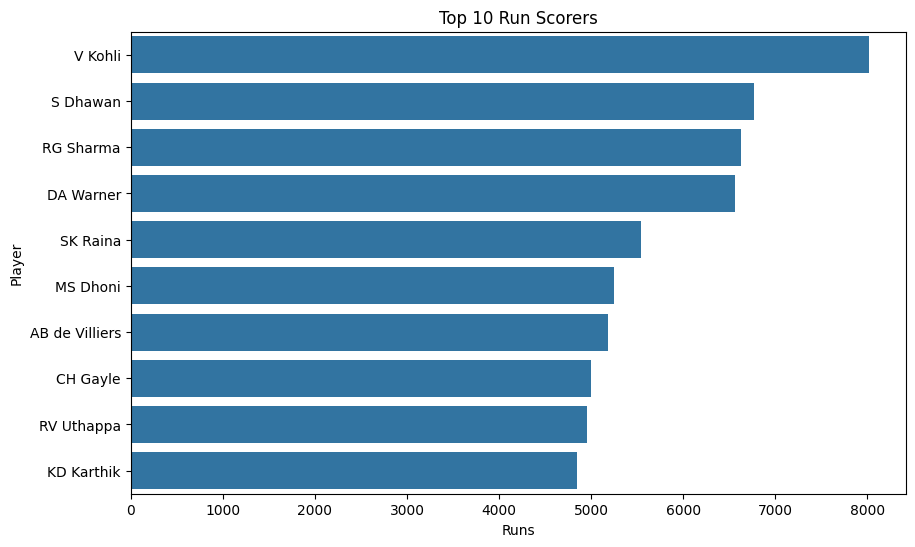

In [14]:
top10 = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Player")

plt.show()

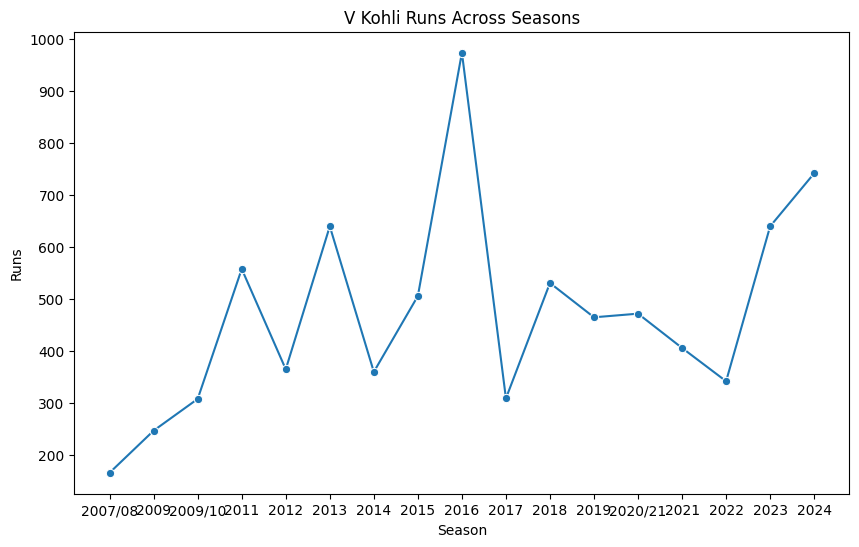

In [15]:
player = "V Kohli"

player_data = season_player_runs[season_player_runs["batter"] == player]

plt.figure(figsize=(10,6))
sns.lineplot(data=player_data, x="season", y="batsman_runs", marker="o")

plt.title(f"{player} Runs Across Seasons")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

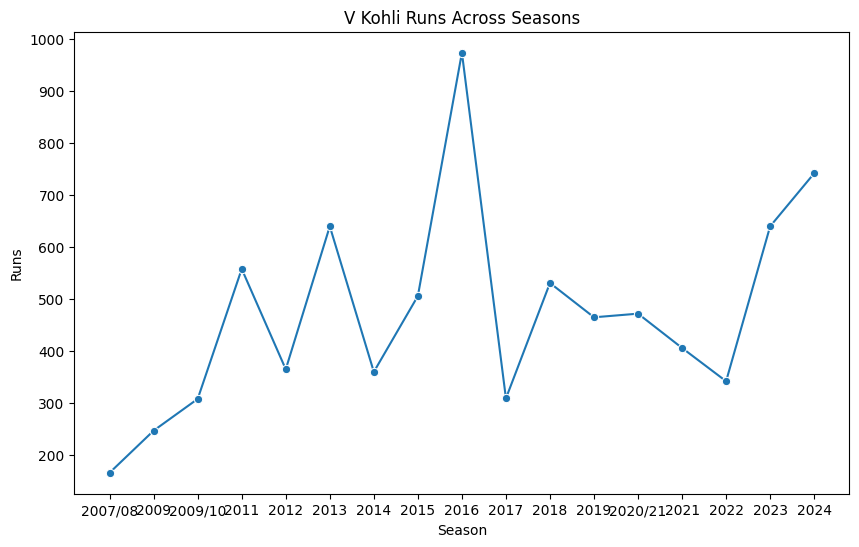

In [16]:
player = "V Kohli"

player_data = season_player_runs[season_player_runs["batter"] == player]

plt.figure(figsize=(10,6))
sns.lineplot(data=player_data, x="season", y="batsman_runs", marker="o")

plt.title(f"{player} Runs Across Seasons")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

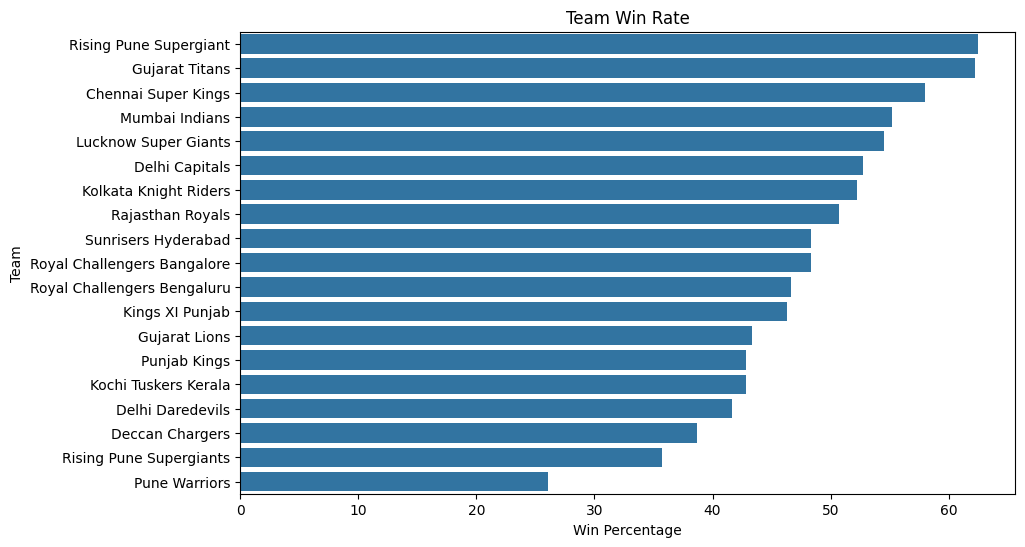

In [17]:
win_rate = win_rate.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=win_rate.values, y=win_rate.index)

plt.title("Team Win Rate")
plt.xlabel("Win Percentage")
plt.ylabel("Team")

plt.show()

In [18]:
summary = pd.DataFrame({
    "Total Runs": runs,
    "Strike Rate": strike_rate
})

summary.to_csv("/content/player_summary.csv")

print("Summary exported to /content/player_summary.csv")

Summary exported to /content/player_summary.csv
